## Understanding the 3-Minute PID Data

Each row represents **one PID (Proportional–Integral–Derivative) control loop during one 3-minute time window**.

### How to Read One Row

**1. Identify the loop and time**
- **`LoopId`** — Which PID control loop?
- **`resulttime`** — When was the measurement recorded?

**2. Check overall performance**
- **`OverallUptime`** — Was the loop available/running?
- **`OverallHealth`** — Overall health score of the loop.
- **`OverallOCE`** — **Overall Control Effectiveness**, the main performance KPI.

OCE connects three main factors:

**OCE = Time in Normal Mode × Time Not Saturated × Percent Good Error**

**3. Understand WHY OCE is high or low**
- **`PercentageTimeInNormalMode`** — How often the controller operated normally.
- **`PercentTimeSaturated`** — How often the **CO (Controller Output)** reached its operating limit.
- **`AbsErrGoodFrac`** — Fraction of time the control error was considered acceptable.
- **`AAE` (Average Absolute Error)** — Average size of the difference between the process and its target.
- **`StictionValue`** — Indicator of possible valve sticking/friction.

**4. Understand what the process/controller was doing**
- **`PV_Average`** — Average **PV (Process Variable)**, the actual measured process value.
- **`PVVariance`** — How much the PV varied.
- **`NormalizedVariation`** — Process variation expressed on a normalized scale.
- **`COTravel`** — How much the Controller Output moved.
- **`ReversalsPerHour`** — How often the controller output changed direction.

### How Everything Connects

**PID Loop + Time**  
↓  
**Overall Performance (OCE)**  
↓  
**OCE Components → Why is performance low/high?**  
↓  
**PV & CO Metrics → What was the process/controller actually doing?**  
↓  
**Compare across time and loops (Benchmarking)**  
↓  
**Identify performance gaps → Estimate economic impact ($/day)**

### Process Side: 
**`AbsErrGoodFrac + AAE + PV_Average + PVVariance + NormalizedVariation`**

### Controller Side: 
**`COTravel + ReversalsPerHour + PercentTimeSaturated + StictionValue`**

**Key terms:**  
**PV = Process Variable** (what we measure)  
**SP = Setpoint** (what we want)  
**CO = Controller Output** (what the controller changes)  
**Error = PV − SP** (difference between actual and target)

***At July 1, 2025 00:00, Loop 5 was fully available and operating in Normal Mode. It showed no stiction according to the provided metric. However, its Overall OCE was only 43.33%. The low OCE appears to be associated with the good-error fraction (43.33%), rather than the loop being outside Normal Mode. The process variable averaged about 3,459 with measurable variation, while the controller output was actively moving and reversing direction.***

In [22]:
import pandas as pd

columns = [
    "LoopId",
    "resulttime",
    "OverallUptime",
    "StictionValue",
    "OverallHealth",
    "OverallOCE",
    "PercentageTimeInNormalMode",
    "AbsErrGoodFrac",
    "AAE",
    "NormalizedVariation",
    "PV_Average",
    "PVVariance",
    "COTravel",
    "ReversalsPerHour",
    "PercentTimeSaturated"
]

df = pd.read_csv(
    "../data/raw/3-minute data Jul.csv",
    header=None,
    names=columns
)

print(display(df.head(10)))

,LoopId,resulttime,OverallUptime,StictionValue,OverallHealth,OverallOCE,PercentageTimeInNormalMode,AbsErrGoodFrac,AAE,NormalizedVariation,PV_Average,PVVariance,COTravel,ReversalsPerHour,PercentTimeSaturated
0,5,2025-07-01 00:00:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,63.214645,4.215731,3459.438232,3004.931641,0.389972,120.0,0.0
1,5,2025-07-01 00:03:00.0000000 +00:00,100.0,0.0,58.333333,41.111111,1.0,0.411111,52.528877,3.696444,3459.736816,3519.830811,0.407352,100.0,0.0
2,5,2025-07-01 00:06:00.0000000 +00:00,100.0,0.0,63.664583,36.666668,1.0,0.366667,40.776787,2.744100,3439.315186,1320.311401,0.355343,80.0,0.0
3,5,2025-07-01 00:09:00.0000000 +00:00,100.0,0.0,58.333333,43.333332,1.0,0.433333,54.010696,3.581736,3459.701416,1991.939819,0.460078,180.0,0.0
4,5,2025-07-01 00:12:00.0000000 +00:00,100.0,0.0,58.333333,36.666668,1.0,0.366667,56.769093,3.680142,3471.993652,2706.926270,0.364381,120.0,0.0
5,5,2025-07-01 00:15:00.0000000 +00:00,100.0,0.0,58.333333,28.888889,1.0,0.288889,70.660530,4.868598,3497.090332,2741.852051,0.629808,180.0,0.0
6,5,2025-07-01 00:18:00.0000000 +00:00,100.0,0.0,58.333333,24.444445,1.0,0.244444,65.464050,3.959182,3521.630371,2824.932861,0.276270,80.0,0.0
7,5,2025-07-01 00:21:00.0000000 +00:00,100.0,0.0,83.511577,86.666664,1.0,0.866667,26.801765,1.791444,3372.719971,859.642273,0.131963,60.0,0.0
8,5,2025-07-01 00:24:00.0000000 +00:00,100.0,0.0,58.333333,33.333336,1.0,0.333333,68.247078,4.711651,3355.276611,1688.857178,0.505975,160.0,0.0
9,5,2025-07-01 00:27:00.0000000 +00:00,100.0,0.0,61.157808,85.555557,1.0,0.855556,34.887478,2.864425,3435.649170,3434.660889,0.226443,240.0,0.0


None


In [ ]:
# Dataset overview
print("Dataset shape:", df.shape)
print("\nTime range:")
print("Start:", df["resulttime"].min())
print("End:", df["resulttime"].max())

print("\nNumber of unique loops:", df["LoopId"].nunique())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

### Dataset Structure

This dataset contains **3-minute PID loop data for one paper machine during July 2025**.

- **Time period:** July 1, 2025 – July 31, 2025
- **Time resolution:** Every 3 minutes
- **Unique PID loops:** 94
- **Total observations:** 1,201,478 rows
- **Variables:** 15

The **94 unique loops** represent 94 different PID control loops operating within the same paper machine. A loop is a specific control system, not necessarily a unique process variable. For example, multiple loops could control pressure or temperature at different locations in the machine.

Conceptually, the dataset looks like:

**One Paper Machine**  
→ **94 PID Control Loops**  
→ **Measured every 3 minutes**  
→ **July 1 – July 31**  
→ **Performance metrics for each loop (OCE, error, variation, controller behavior, etc.)**

Each row therefore represents:

**One PID Loop + One 3-minute time window + Its performance metrics**

In [23]:
df["resulttime"] = pd.to_datetime(df["resulttime"], utc=True)

print(df["resulttime"].dtype)

datetime64[ns, UTC]


In [24]:
# 1. Missing values
display(df.isnull().sum())

# 2. Duplicate observations
duplicates = df.duplicated(subset=["LoopId", "resulttime"]).sum()
print("Duplicate LoopId + resulttime:", duplicates)

# 3. Number of observations for each loop
loop_counts = df.groupby("LoopId").size().sort_values()

display(loop_counts)
display(loop_counts.describe())

LoopId                             0
resulttime                         0
OverallUptime                      0
StictionValue                 348207
OverallHealth                      0
OverallOCE                      2280
PercentageTimeInNormalMode         0
AbsErrGoodFrac                     0
AAE                             1176
NormalizedVariation                0
PV_Average                      1176
PVVariance                      1176
COTravel                        2280
ReversalsPerHour                2280
PercentTimeSaturated            2280
dtype: int64

Duplicate LoopId + resulttime: 0


LoopId
420        3
422        3
294       11
295       11
441     1670
       ...  
458    14235
462    14235
312    14769
439    14857
5      14880
Length: 94, dtype: int64

count       94.000000
mean     12781.680851
std       3352.384278
min          3.000000
25%      13607.000000
50%      13607.000000
75%      14067.000000
max      14880.000000
dtype: float64

### Missing Values — Key Observations

- **StictionValue**
  - 348,207 missing observations
  - 28.98% of the dataset
  - Largest amount of missing data among all variables
  - Requires clarification before imputation or removal

- **OverallOCE, ReversalsPerHour, COTravel, PercentTimeSaturated**
  - 2,280 missing observations each
  - Approximately 0.19% of the dataset
  - Identical missing counts may indicate a shared missing-data pattern

- **AAE, PV_Average, PVVariance**
  - 1,176 missing observations each
  - Approximately 0.10% of the dataset
  - Identical missing counts may indicate that these variables are unavailable for the same observations

- **Remaining Variables**
  - No missing values identified

### Data Quality Decision

- No missing values were removed or imputed during the initial EDA.
- Missing-value treatment is pending clarification of the data-generation process and variable definitions.
- Original missing values are preserved for subsequent analysis.

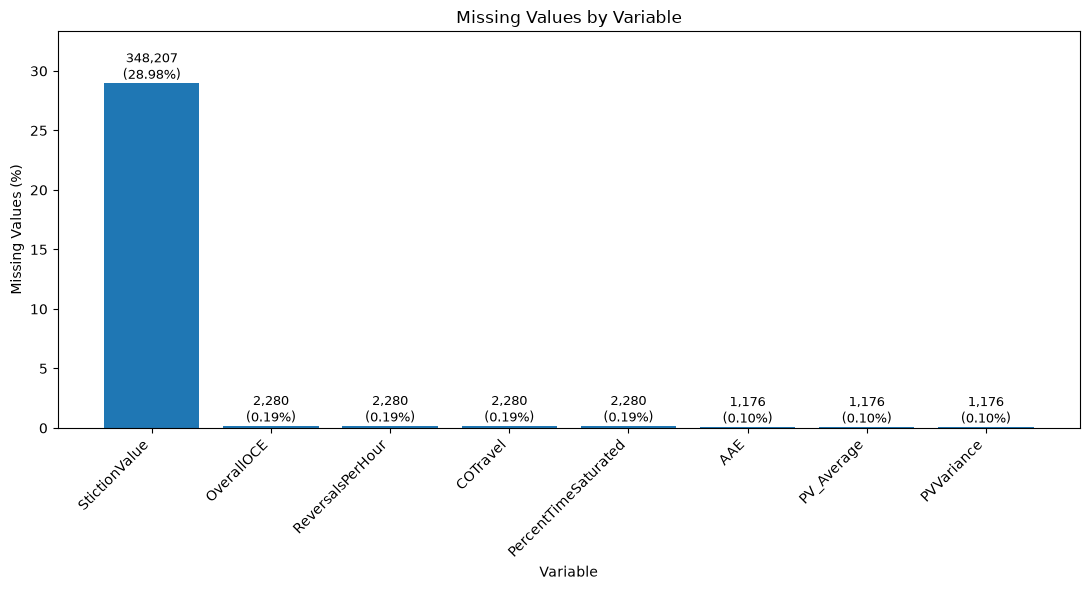

In [27]:
import matplotlib.pyplot as plt

# Missing value count and percentage
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

# Keep only columns with missing values
missing = (
    pd.DataFrame({
        "Missing Count": missing_count,
        "Missing %": missing_pct
    })
    .query("`Missing Count` > 0")
    .sort_values("Missing %", ascending=False)
)

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    missing.index,
    missing["Missing %"]
)

# Add count + percentage on top of each bar
for bar, count, pct in zip(
    bars,
    missing["Missing Count"],
    missing["Missing %"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title("Missing Values by Variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Missing Values (%)")

plt.xticks(rotation=45, ha="right")

# Extra space for labels
ax.set_ylim(0, missing["Missing %"].max() * 1.15)

plt.tight_layout()
plt.show()

In [33]:
df.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
LoopId,1201478.0,440.127624,121.245252,5.000000,5.000000,297.000000,404.000000,435.000000,459.000000,685.000000,699.000000,6.990000e+02
OverallUptime,1201478.0,99.890768,2.442232,32.967033,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.000000e+02
StictionValue,853271.0,0.006531,0.055932,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.303932,9.951786e-01
OverallHealth,1201478.0,77.495114,23.548039,0.000000,0.000000,33.333333,58.333333,83.111475,100.000000,100.000000,100.000000,1.000000e+02
OverallOCE,1199198.0,54.442876,38.497919,0.000000,0.000000,0.000000,13.333334,61.111111,94.444443,100.000000,100.000000,1.000000e+02
PercentageTimeInNormalMode,1201478.0,0.941156,0.235111,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
AbsErrGoodFrac,1201478.0,0.641176,0.357077,0.000000,0.000000,0.000000,0.366667,0.733333,1.000000,1.000000,1.000000,1.000000e+00
AAE,1200302.0,15.974572,65.422490,0.000000,0.000000,0.011916,0.084603,0.405208,3.577054,119.133110,235.024608,5.870490e+03
NormalizedVariation,1201478.0,4131.514453,207777.150991,0.000000,0.000000,0.175141,0.627123,1.805043,5.436326,71.398355,1879.107390,6.009416e+07
PV_Average,1200302.0,377.645524,851.024643,-499.672272,1.371895,2.950845,7.124039,59.979126,327.136299,1498.027112,5498.074473,1.151961e+04


### Key Observations

- **Overall Uptime**
  - Median: 100%
  - Very low variation
  - Most observations indicate full uptime

- **Overall Health**
  - Median: ~83%
  - Moderate variation across observations

- **Overall OCE**
  - Median: ~61%
  - Wide distribution (Q1: ~13%, Q3: ~94%)
  - Indicates substantial variation in control effectiveness

- **Time in Normal Mode**
  - Median: 100%
  - Most observations remain in normal operating mode

- **Good Error Fraction**
  - Median: ~73%
  - Considerable variation across observations

- **Percent Time Saturated**
  - Median: 0%
  - At least 75% of observations have no recorded saturation

### Initial Finding

- Uptime and Normal Mode are consistently high.
- OCE and Good Error Fraction show substantially greater variation.
- Further analysis is needed to determine the factors associated with OCE variation.

> **Scope:** Statistics are pooled across all 94 PID loops and should not be interpreted as machine-level performance.

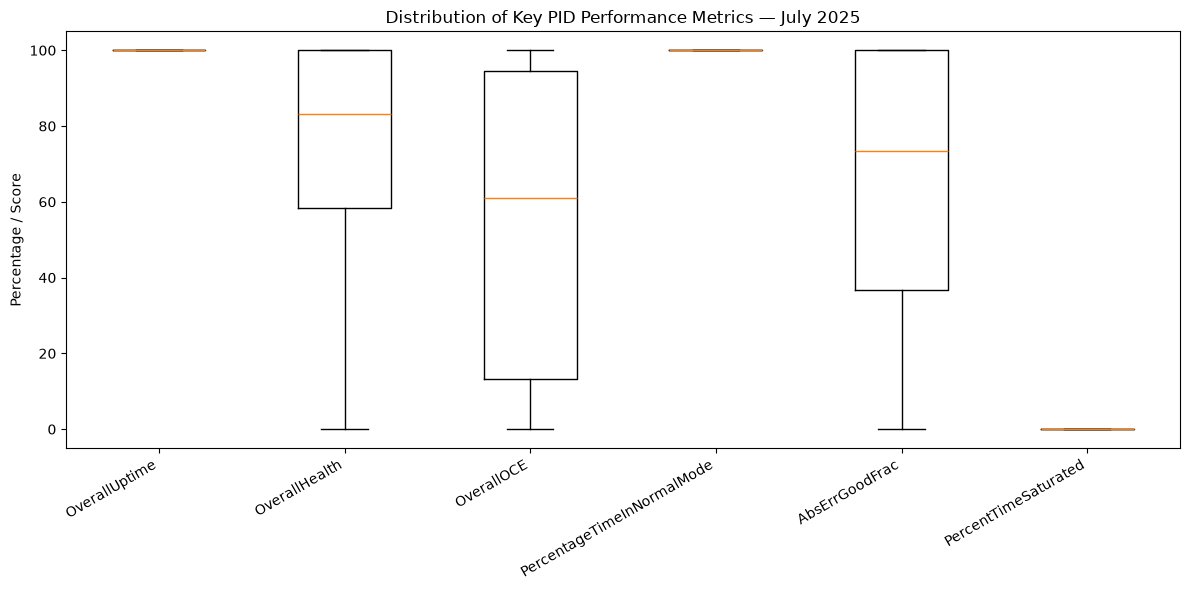

In [35]:
import matplotlib.pyplot as plt

plot_df = df[
    [
        "OverallUptime",
        "OverallHealth",
        "OverallOCE",
        "PercentageTimeInNormalMode",
        "AbsErrGoodFrac",
        "PercentTimeSaturated"
    ]
].copy()

# Convert fractions to percentage scale
plot_df["PercentageTimeInNormalMode"] *= 100
plot_df["AbsErrGoodFrac"] *= 100
plot_df["PercentTimeSaturated"] *= 100

plt.figure(figsize=(12, 6))

plt.boxplot(
    [plot_df[col].dropna() for col in plot_df.columns],
    tick_labels=plot_df.columns,
    showfliers=False
)

plt.title("Distribution of Key PID Performance Metrics — July 2025")
plt.ylabel("Percentage / Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()